# Library

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

# Paths

In [2]:
BASE     = Path(".")
NB2_PATH = BASE / "nb2"
NB3_PATH = BASE / "nb3"   # same folder as nodes.csv, edges.csv, etc
NB3_PATH.mkdir(parents=True, exist_ok=True)

# Input files from NB2
HISN_PARQUET   = NB2_PATH / "hisn_final.parquet"
USER_STATS_CSV = NB2_PATH / "user_stats.csv"

# Load HISN and User Stats

In [3]:
hisn = pd.read_parquet(HISN_PARQUET)
user_stats = pd.read_csv(USER_STATS_CSV)

print("HISN shape:", hisn.shape)
print("User stats shape (global):", user_stats.shape)

# Keep only users that appear in HISN
hisn_users = hisn["user_id"].astype(str).unique()
user_stats["user_id"] = user_stats["user_id"].astype(str)
user_stats_hisn = (
    user_stats[user_stats["user_id"].isin(hisn_users)]
    .reset_index(drop=True)
)

print("User stats (HISN only):", user_stats_hisn.shape)
print("Example user_stats columns:", user_stats_hisn.columns.tolist())

HISN shape: (7378, 31)
User stats shape (global): (69587, 10)
User stats (HISN only): (2755, 10)
Example user_stats columns: ['user_id', 'n_reviews_user', 'avg_rating_user', 'std_rating_user', 'frac_verified_user', 'avg_len_user', 'dup_ratio_user', 'max_reviews_per_day', 'day_entropy', 'avg_text_sim']


# Build user feature matrix and standardization

Tujuan block ini:

1. Pilih kolom fitur user yang relevan untuk SGDCTH:
- dup_ratio_user,
- avg_text_sim,
- max_reviews_per_day,
- day_entropy,
- dan fitur lain seperti n_reviews_user, avg_rating_user, dll.

2. Handle missing values (isi dengan 0).
3. Standardize semua fitur pakai StandardScaler supaya:

In [4]:
candidate_feats = [
    "n_reviews_user",
    "avg_rating_user",
    "std_rating_user",
    "frac_verified_user",
    "avg_len_user",
    "dup_ratio_user",
    "max_reviews_per_day",
    "day_entropy",
    "avg_text_sim",
    "n_unique_items",
]

In [5]:
feat_cols = [c for c in candidate_feats if c in user_stats_hisn.columns]
print("Using feature columns:", feat_cols)

Using feature columns: ['n_reviews_user', 'avg_rating_user', 'std_rating_user', 'frac_verified_user', 'avg_len_user', 'dup_ratio_user', 'max_reviews_per_day', 'day_entropy', 'avg_text_sim']


In [6]:
# Raw feature matrix (fill missing with 0)
X_raw = user_stats_hisn[feat_cols].fillna(0.0).to_numpy()

# Standardize to zero mean, unit variance (important for DBSCAN)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (2755, 9)


# DBSCAN Clustering

- Menjalankan DBSCAN pada ruang fitur user standar.
- eps = 0.8: radius di feature space (set hyperparameter).
- min_samples = 3: minimal user untuk dianggap cluster (bukan noise).

Output:
- cluster_labels (integer label per user, -1 = noise).
- Ditambahkan sebagai kolom cluster di user_stats_hisn.

Ini adalah jantung dari group detection:
kita mau cari group user yang punya pola mirip di vector behavioural features.

In [7]:
eps = 0.9
min_samples = 3

In [8]:
from sklearn.metrics import *

In [9]:
def evaluate_dbscan(X, labels):
    """Return cluster evaluation metrics while ignoring noise."""
    mask = labels != -1
    if mask.sum() < 3:
        return None
    
    if len(set(labels[mask])) <= 1:
        return None
    
    sil = silhouette_score(X[mask], labels[mask])
    dbi = davies_bouldin_score(X[mask], labels[mask])
    chi = calinski_harabasz_score(X[mask], labels[mask])
    noise = (labels == -1).mean()
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    return sil, dbi, chi, noise, clusters


eps_values = np.linspace(0.1, 1.5, 15)
min_samples_values = [3, 5, 8, 10, 12]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        
        db = DBSCAN(eps=eps, min_samples=ms, metric="euclidean")
        labels = db.fit_predict(X)
        
        metrics = evaluate_dbscan(X, labels)
        if metrics is None:
            continue
        
        sil, dbi, chi, noise, clusters = metrics
        
        results.append([
            eps, ms, sil, dbi, chi, noise, clusters
        ])

results_df = pd.DataFrame(results, columns=[
    "eps", "min_samples",
    "silhouette", "DBI", "CHI", "noise_ratio", "n_clusters"
])

print("Top results sorted by silhouette score:")
display(results_df.sort_values("silhouette", ascending=False).head(10))

print("\nTop results sorted by noise ratio close to fraud range:")
display(
    results_df[(results_df["noise_ratio"] > 0.1) & (results_df["noise_ratio"] < 0.4)]
    .sort_values("silhouette", ascending=False)
    .head(10)
)

Top results sorted by silhouette score:


,eps,min_samples,silhouette,DBI,CHI,noise_ratio,n_clusters
64,1.3,12,0.584392,0.730604,461.318644,0.088203,5
72,1.5,8,0.583577,0.869903,404.574716,0.062795,7
74,1.5,12,0.580936,0.880127,488.839516,0.075499,5
73,1.5,10,0.578777,0.879208,429.782887,0.069328,6
69,1.4,12,0.578713,0.809190,474.650918,0.079129,5
67,1.4,8,0.578638,0.815922,419.433913,0.072595,6
68,1.4,10,0.578110,0.819226,468.731044,0.077314,5
62,1.3,8,0.568451,0.780067,355.779964,0.075862,7
63,1.3,10,0.566613,0.762227,377.288246,0.082396,6
71,1.5,5,0.564415,0.922755,278.731481,0.054446,10



Top results sorted by noise ratio close to fraud range:


,eps,min_samples,silhouette,DBI,CHI,noise_ratio,n_clusters
18,0.4,10,0.531070,0.725382,1165.632259,0.178584,10
23,0.5,10,0.527953,0.747100,1154.967546,0.171325,10
12,0.3,8,0.527776,0.699871,1030.223866,0.180036,11
17,0.4,8,0.526735,0.713233,1060.044361,0.173140,11
24,0.5,12,0.526590,0.786853,1251.211902,0.176044,9
14,0.3,12,0.520741,0.637657,1214.164372,0.204356,9
9,0.2,12,0.514526,0.620924,1128.326222,0.225408,9
8,0.2,10,0.513457,0.582100,993.072607,0.212704,11
22,0.5,8,0.510190,0.742446,833.541004,0.154991,13
29,0.6,12,0.509228,0.795544,969.106226,0.162250,11


Cluster with eps = 1.3 and min_samples = 12 will be chosen because it will be the best for fraud detection, not just mere clustering

In [10]:
eps = 1.3
min_samples = 12

In [11]:
db = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
cluster_labels = db.fit_predict(X)

In [12]:
user_stats_hisn["cluster"] = cluster_labels

print("Cluster label counts (including -1 as noise):")
print(user_stats_hisn["cluster"].value_counts().sort_index())

Cluster label counts (including -1 as noise):
cluster
-1     243
 0    2283
 1      16
 2      78
 3     107
 4      28
Name: count, dtype: int64


# Cluster Level Summary and Suspicious Cluster Heuristics

1. Aggregate user-level features → cluster-level summary:
- avg_dup_ratio
- avg_text_sim
- avg_max_reviews_day
- avg_day_entropy
- avg_n_reviews
- n_users per cluster

2. Buat cluster_eval = hanya cluster non-noise (cluster != -1).

3. Hitung threshold heuristik:
- dup_ratio ≥ Q75 → spam-like
- avg_text_sim ≥ Q75 → template-like
- burstiness ≥ Q75 → spam burst
- day_entropy ≤ Q25 → low diversity (spam signature)

4. Tandai cluster is_suspicious jika semua kondisi terpenuhi.

In [13]:
cluster_summary = (
    user_stats_hisn
    .groupby("cluster")
    .agg(
        n_users=("user_id", "nunique"),
        avg_dup_ratio=("dup_ratio_user", "mean"),
        avg_text_sim=("avg_text_sim", "mean"),
        avg_max_reviews_day=("max_reviews_per_day", "mean"),
        avg_day_entropy=("day_entropy", "mean"),
        avg_n_reviews=("n_reviews_user", "mean"),
    )
    .reset_index()
)

In [14]:
print("Cluster summary (including -1 noise):")
cluster_summary.head()

Cluster summary (including -1 noise):


,cluster,n_users,avg_dup_ratio,avg_text_sim,avg_max_reviews_day,avg_day_entropy,avg_n_reviews
0,-1,243,0.842936,0.585172,3.139918,7.191729e-01,6.765432
1,0,2283,1.000000,0.997701,2.199737,-1.000000e-10,2.199737
2,1,16,1.000000,0.481544,2.000000,6.931472e-01,4.000000
3,2,78,1.000000,0.621079,2.000000,6.931472e-01,4.000000
4,3,107,1.000000,1.000000,2.093458,-1.000000e-10,2.093458


In [15]:
cluster_eval = cluster_summary[cluster_summary["cluster"] != -1].copy()
print("Num non-noise clusters:", len(cluster_eval))

Num non-noise clusters: 5


In [16]:
if not cluster_eval.empty:
    thr_dup     = cluster_eval["avg_dup_ratio"].quantile(0.75)
    thr_sim     = cluster_eval["avg_text_sim"].quantile(0.75)
    thr_burst   = cluster_eval["avg_max_reviews_day"].quantile(0.75)
    thr_entropy = cluster_eval["avg_day_entropy"].quantile(0.25)  # low entropy = suspicious

    print("Heuristic thresholds:")
    print("  dup_ratio >= ", thr_dup)
    print("  avg_text_sim >= ", thr_sim)
    print("  max_reviews_per_day >= ", thr_burst)
    print("  day_entropy <= ", thr_entropy)

    def suspicious_row(row):
        return (
            (row["n_users"] >= 3) &
            (row["avg_dup_ratio"]      >= thr_dup) &
            (row["avg_text_sim"]      >= thr_sim) &
            (row["avg_max_reviews_day"] >= thr_burst) &
            (row["avg_day_entropy"]    <= thr_entropy)
        )

    cluster_eval["is_suspicious"] = cluster_eval.apply(suspicious_row, axis=1)
else:
    # If there are no non-noise clusters, just create the flag column for consistency
    cluster_eval["is_suspicious"] = pd.Series([], dtype=bool)

Heuristic thresholds:
  dup_ratio >=  1.0
  avg_text_sim >=  0.9977012818309243
  max_reviews_per_day >=  2.0934579439252334
  day_entropy <=  -1.0000000826903709e-10


In [17]:
suspicious_clusters = cluster_eval[cluster_eval["is_suspicious"] == True]["cluster"].tolist()
print("Suspicious clusters:", suspicious_clusters)

Suspicious clusters: [0, 3]


# SGDCTH Cluster Score

1. Ambil beberapa sinyal cluster:
- avg_dup_ratio,
- avg_text_sim,
- avg_max_reviews_day,
- avg_day_entropy

2. Normalisasi ke [0,1].

3. Gabungkan dengan weighted sum:
score tinggi --> cluster lebih suspicious.

In [18]:
if not cluster_eval.empty:

    def minmax(col):
        v = cluster_eval[col]
        return (v - v.min()) / (v.max() - v.min() + 1e-9)

    z_dup   = minmax("avg_dup_ratio")
    z_sim   = minmax("avg_text_sim")
    z_burst = minmax("avg_max_reviews_day")
    # Lower entropy = more suspicious => invert after minmax
    z_ent   = 1.0 - minmax("avg_day_entropy")

    cluster_eval["sgdcth_score"] = (
        0.30 * z_dup +
        0.30 * z_sim +
        0.25 * z_burst +
        0.15 * z_ent
    )

    cluster_eval = cluster_eval.sort_values("sgdcth_score", ascending=False).reset_index(drop=True)

    print("Top clusters by SGDCTH score:")
    display(cluster_eval.head(10))
else:
    # If cluster_eval is empty, create the column for consistency
    cluster_eval["sgdcth_score"] = pd.Series([], dtype=float)

Top clusters by SGDCTH score:


,cluster,n_users,avg_dup_ratio,avg_text_sim,avg_max_reviews_day,avg_day_entropy,avg_n_reviews,is_suspicious,sgdcth_score
0,0,2283,1.0,0.997701,2.199737,-1.000000e-10,2.199737,True,6.986699e-01
1,3,107,1.0,1.000000,2.093458,-1.000000e-10,2.093458,True,5.669761e-01
2,2,78,1.0,0.621079,2.000000,6.931472e-01,4.000000,False,8.074067e-02
3,4,28,1.0,0.536712,2.000000,6.931472e-01,4.000000,False,3.192214e-02
4,1,16,1.0,0.481544,2.000000,6.931472e-01,4.000000,False,2.164042e-10


# Extract Spammer Users, Fallback, Save Outputs, Plot

We got some goals here
1. To decide which cluster is suspicious <br>
2. From there we gonna take "spammer users" as the user that are suspicious
3. if there is no, fallback top 5%

In [24]:
if suspicious_clusters:
    spammer_users = user_stats_hisn[user_stats_hisn["cluster"].isin(suspicious_clusters)].copy()
    spammer_users = spammer_users.merge(
        cluster_eval[["cluster", "sgdcth_score"]],
        on="cluster",
        how="left"
    )
    heuristic_based = True
else:
    print("Fallback")
    # Fallback: if no cluster passes strict heuristics,
    # take top q fraction by SGDCTH score as suspicious clusters.
    heuristic_based = False
    if not cluster_eval.empty:
        top_q = 0.05  # top 5% clusters by score as fallback
        k_fallback = max(1, int(len(cluster_eval) * top_q))
        fallback_clusters = cluster_eval.head(k_fallback)["cluster"].tolist()
        print(f"No clusters passed heuristics, using fallback top-{top_q*100:.1f}% clusters:", fallback_clusters)

        spammer_users = user_stats_hisn[user_stats_hisn["cluster"].isin(fallback_clusters)].copy()
        spammer_users = spammer_users.merge(
            cluster_eval[["cluster", "sgdcth_score"]],
            on="cluster",
            how="left"
        )
    else:
        # No clusters at all → empty
        spammer_users = user_stats_hisn.iloc[0:0].copy()

In [25]:
print("Num spammer users detected:", len(spammer_users))
spammer_users.head()

Num spammer users detected: 2390


,user_id,n_reviews_user,avg_rating_user,std_rating_user,frac_verified_user,avg_len_user,dup_ratio_user,max_reviews_per_day,day_entropy,avg_text_sim,cluster,sgdcth_score
0,AE2AGER57FLQUVQL42BNNATXIBUQ,3,4.0,0.0,1.0,12.0,1.0,3,-1.000000e-10,1.0,0,0.69867
1,AE2AGRHBJANSI6X6FZIX5P3JJMKQ,2,1.0,0.0,1.0,39.0,1.0,2,-1.000000e-10,1.0,0,0.69867
2,AE2AHLMGFMGC3XTLKUKZ4CPSN5GA,2,5.0,0.0,1.0,4.0,1.0,2,-1.000000e-10,1.0,0,0.69867
3,AE2D63CLUOY2B2PMYX7JLBB2XY6A,2,5.0,0.0,1.0,76.0,1.0,2,-1.000000e-10,1.0,0,0.69867
4,AE2EONWIPGUP6W3OZGQAK72MVNOA,2,5.0,0.0,1.0,48.0,1.0,2,-1.000000e-10,1.0,0,0.69867


In [26]:
if not spammer_users.empty:
    spammer_users_out = spammer_users[["user_id", "cluster", "sgdcth_score"]].copy()
else:
    spammer_users_out = spammer_users.copy()  # empty frame with same columns

spammer_users_out.to_csv(NB3_PATH / "spammer_users.csv", index=False)
cluster_eval.to_csv(NB3_PATH / "spammer_clusters.csv", index=False)

print("✅ Saved spammer_users.csv and spammer_clusters.csv to", NB3_PATH)

✅ Saved spammer_users.csv and spammer_clusters.csv to nb3


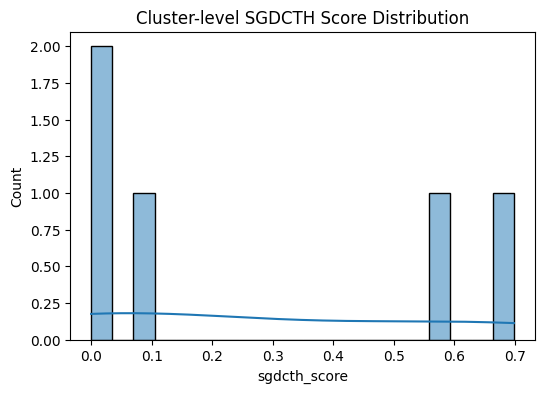

In [27]:
if not cluster_eval.empty:
    plt.figure(figsize=(6, 4))
    sns.histplot(cluster_eval["sgdcth_score"], bins=20, kde=True)
    plt.title("Cluster-level SGDCTH Score Distribution")
    plt.xlabel("sgdcth_score")
    plt.ylabel("Count")
    plt.show()